In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('gym_members_exercise_tracking.csv')
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


#### Calories_Burned kis range mein sabse zyada concentrate hai — members ke beech?

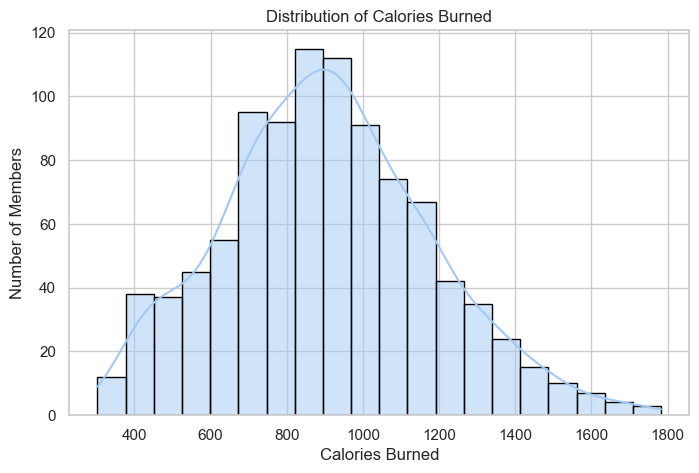

In [8]:
sns.set_palette('pastel')
sns.set_style('whitegrid')
sns.set_context('notebook')

plt.figure(figsize=(8,5))

sns.histplot(df['Calories_Burned'], bins=20, kde=True, edgecolor='black')
plt.title("Distribution of Calories Burned")
plt.xlabel("Calories Burned")
plt.ylabel("Number of Members")

plt.show()

#### Age ka distribution kaisa hai — gym mein kaunsi age group sabse zyada hai?

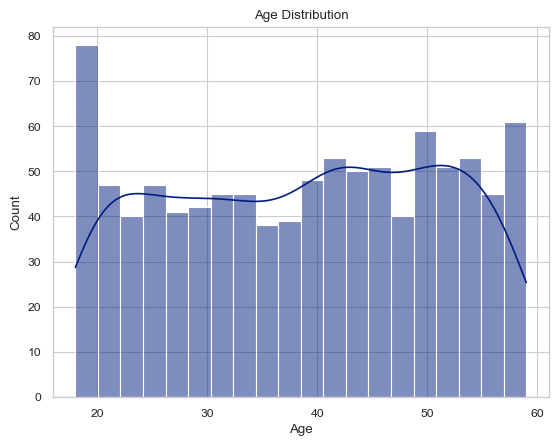

In [25]:
sns.set_palette('dark')
sns.set_style('whitegrid')
sns.set_context('paper')

sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')

plt.show()

#### Workout_Type ke hisaab se average Calories_Burned mein farak hai kya?

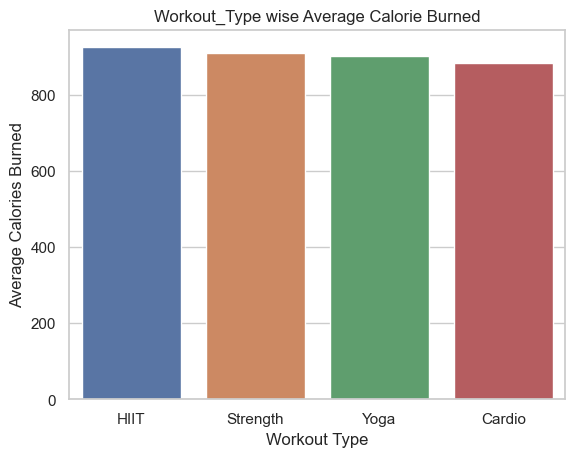

In [26]:
workType_wise_clBurned = df.groupby('Workout_Type')['Calories_Burned'].mean().sort_values(ascending=False)

sns.set_theme(style='whitegrid')

sns.barplot(x=workType_wise_clBurned.index, y=workType_wise_clBurned.values, hue=workType_wise_clBurned.index)
plt.title('Workout_Type wise Average Calorie Burned')
plt.xlabel('Workout Type')
plt.ylabel('Average Calories Burned')

plt.show()

#### Gender ke hisaab se Session_Duration mein koi difference hai?

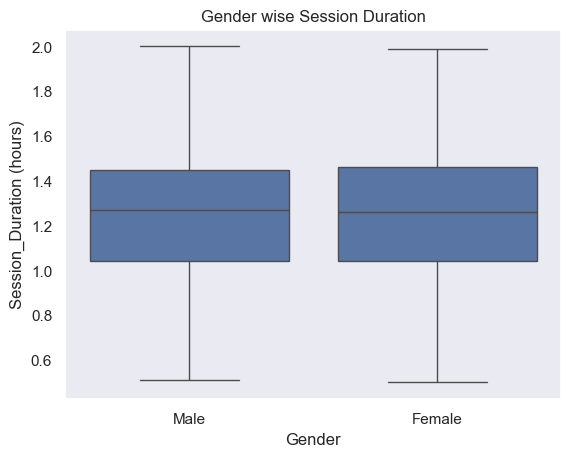

In [42]:
sns.set_style('dark')
sns.set_context('notebook')

sns.boxplot(x=df['Gender'], y=df['Session_Duration (hours)'])
plt.title('Gender wise Session Duration')

plt.show()

#### Experience_Level (1/2/3) ke across Workout_Frequency kaisे change hoti hai?

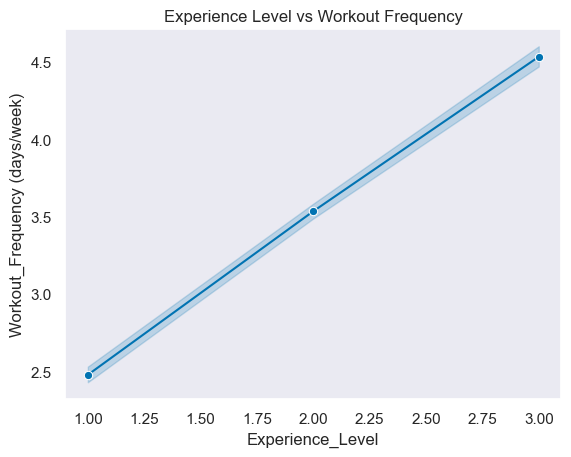

In [48]:
sns.set_palette('colorblind')

sns.lineplot(x='Experience_Level', y='Workout_Frequency (days/week)', data=df, marker='o')
plt.title('Experience Level vs Workout Frequency')

plt.show()

#### Weight (kg) aur Calories_Burned mein koi relationship hai?

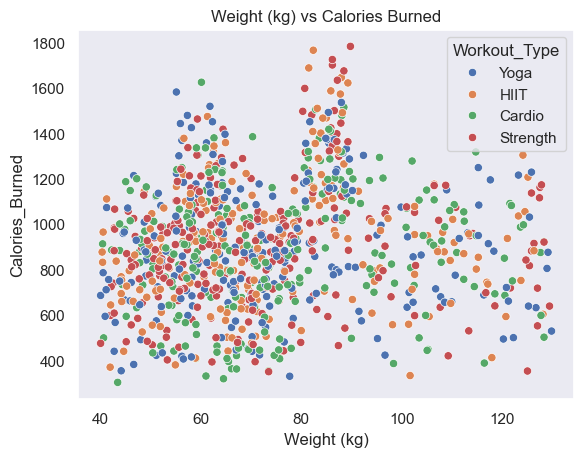

In [58]:
sns.set_palette('deep')
sns.set_style('dark')
sns.set_theme(style='dark')

sns.scatterplot(x='Weight (kg)', y='Calories_Burned', data=df, hue='Workout_Type')
plt.title('Weight (kg) vs Calories Burned')

plt.show()

#### Avg_BPM aur Fat_Percentage — koi correlation dikhta hai?

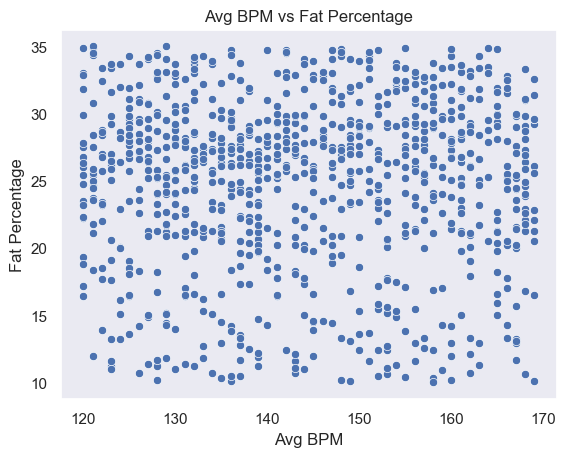

In [61]:
sns.set_palette('deep')
sns.set_style('dark')
sns.set_theme(style='dark')

sns.scatterplot(x='Avg_BPM', y='Fat_Percentage', data=df)
plt.title('Avg BPM vs Fat Percentage')
plt.xlabel('Avg BPM')
plt.ylabel('Fat Percentage')

plt.show()

#### BMI ka distribution kaisa hai — outliers hain kya?

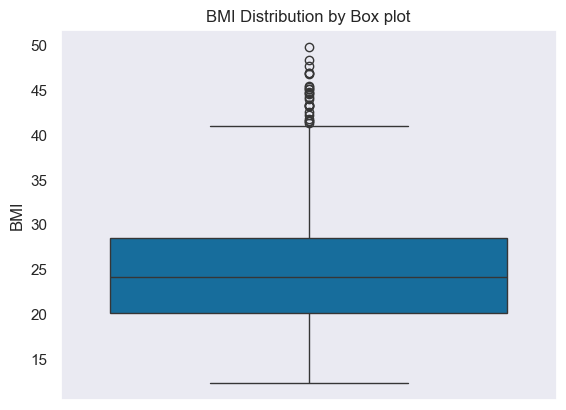

In [67]:
sns.set_palette('colorblind')
sns.set_style('dark')
sns.set_context('notebook')

sns.boxplot(df['BMI'])
plt.title('BMI Distribution by Box plot')

plt.show()

#### Water_Intake (liters) aur Session_Duration mein koi pattern hai?

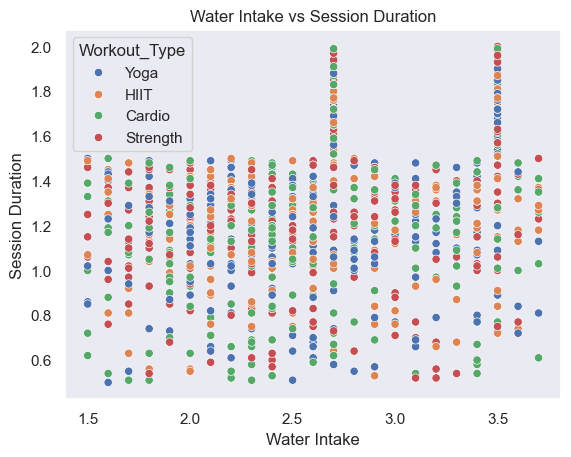

In [73]:
sns.set_palette('deep')
sns.set_style('dark')
sns.set_theme(style='dark')

sns.scatterplot(x='Water_Intake (liters)', y='Session_Duration (hours)', data=df, hue='Workout_Type')
plt.title('Water Intake vs Session Duration')
plt.xlabel('Water Intake')
plt.ylabel('Session Duration')

plt.show()

#### Max_BPM aur Resting_BPM ka relationship kaisa hai — dono saath badhte hain?


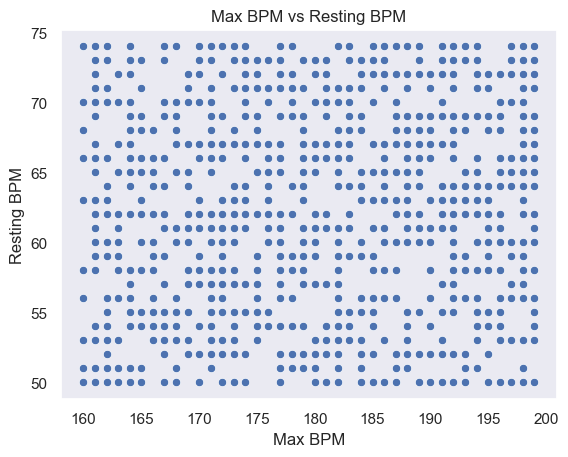

In [77]:
sns.set_palette('deep')
sns.set_style('dark')
sns.set_theme(style='dark')

sns.scatterplot(x='Max_BPM', y='Resting_BPM', data=df)
plt.title('Max BPM vs Resting BPM')
plt.xlabel('Max BPM')
plt.ylabel('Resting BPM')

plt.show()

#### Saare numeric columns (Age, Weight, BMI, Calories_Burned, Fat_Percentage, etc.) ka mutual correlation ek saath dekhna hai.

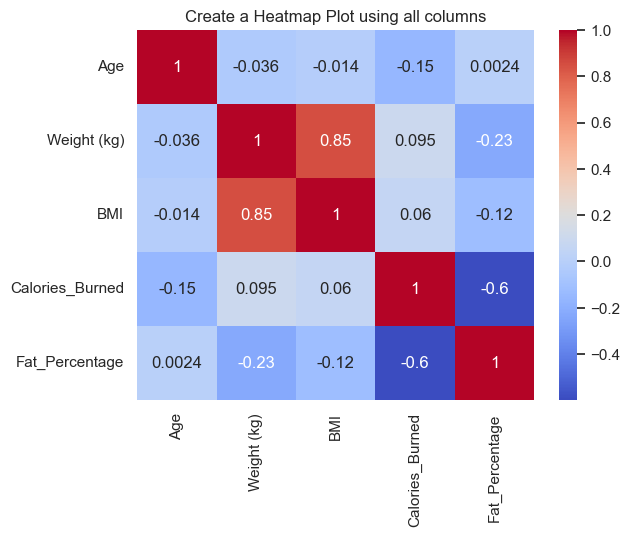

In [91]:
heatmap_data = df[['Age', 'Weight (kg)', 'BMI', 'Calories_Burned', 'Fat_Percentage']].corr()

sns.set_style('dark')
sns.set_theme(style='dark')

sns.heatmap(heatmap_data, cmap='coolwarm', annot=True)
plt.title('Create a Heatmap Plot using all columns')

plt.show()

#### Experience_Level ke hisaab se Fat_Percentage mein farak hai kya (beginner vs expert)?

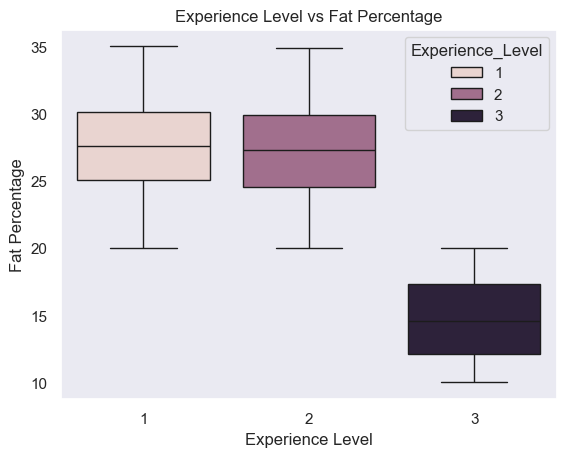

In [98]:
sns.boxplot(x='Experience_Level', y='Fat_Percentage', data=df, hue='Experience_Level')
plt.title('Experience Level vs Fat Percentage')
plt.xlabel('Experience Level')
plt.ylabel('Fat Percentage')

plt.show()

#### Workout_Type ka overall breakdown — kaunsa type members sabse zyada follow karte hain?

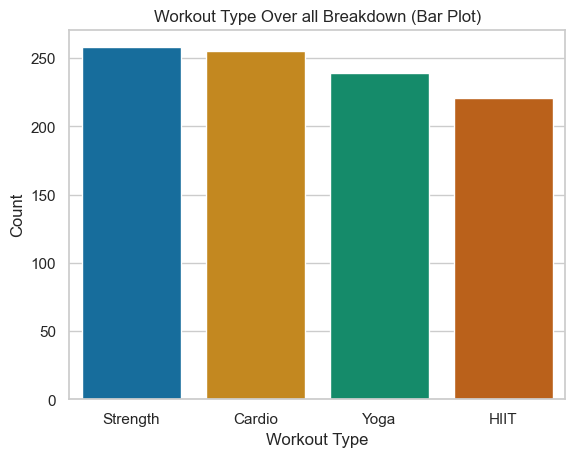

In [104]:
workout_count=df['Workout_Type'].value_counts()

sns.set_style('whitegrid')
sns.set_context('notebook')
sns.set_palette('colorblind')

sns.barplot(x=workout_count.index, y=workout_count.values, hue=workout_count.index)
plt.title('Workout Type Over all Breakdown (Bar Plot)')
plt.xlabel('Workout Type')
plt.ylabel('Count')

plt.show()

#### Gender aur Workout_Type — kya koi gender particular workout type prefer karta dikh raha hai?

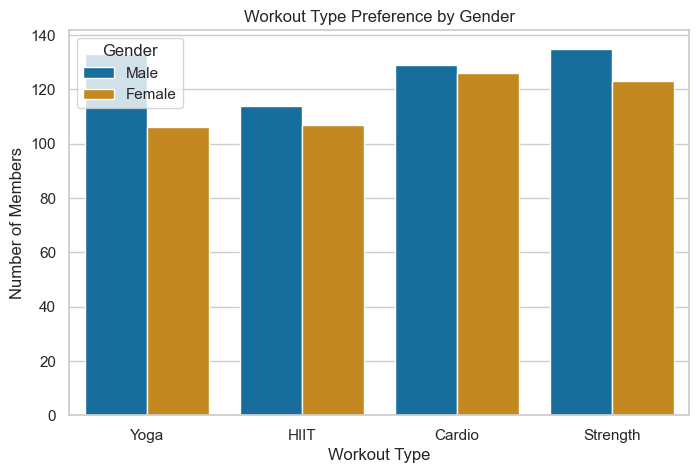

In [110]:
plt.figure(figsize=(8,5))

sns.countplot(x='Workout_Type', hue='Gender', data=df)

plt.title("Workout Type Preference by Gender")
plt.xlabel("Workout Type")
plt.ylabel("Number of Members")

plt.show()

#### Height (m) aur Weight (kg) ka relationship (BMI validate karne ke liye)?

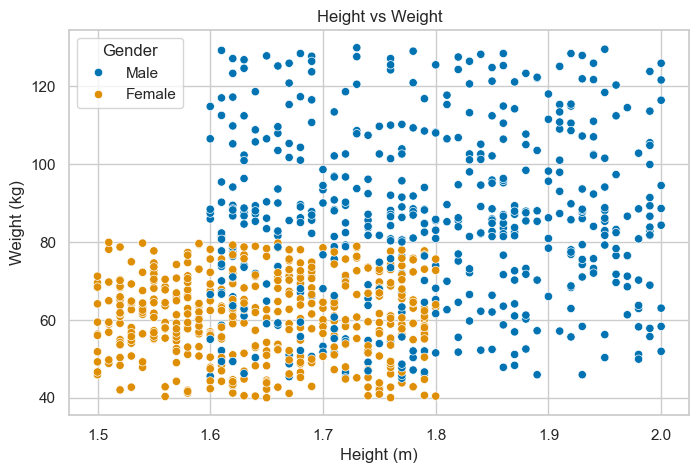

In [112]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Height (m)', y='Weight (kg)', data=df, hue='Gender')

plt.title("Height vs Weight")
plt.xlabel("Height (m)")
plt.ylabel("Weight (kg)")

plt.show()